**3rd ML Model: Neural Network**

Name: Alphin Varghese

In [1]:
import gc, os
from typing import List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
df =pd.read_csv("train.csv")
print("raw shape:", df.shape)
display(df.head())

df2 =df.copy()

raw shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
def g_collect(vs):
    for v in vs:
        if v in globals():
            del globals()[v]
    gc.collect()

def err_fun(y, y_hat):
    return y -y_hat

def mse(y, y_hat):
    e = err_fun(y, y_hat)
    return np.mean(e**2)

def rmse(y, y_hat):
    return np.sqrt(mse(y, y_hat))

def mae(y, y_hat):
    e =np.abs(y -y_hat)
    return np.mean(e)

def sse(y, y_hat):
    e =err_fun(y, y_hat)
    return np.sum(e**2)

def perf(y, y_hat):
    e =err_fun(y, y_hat)
    ss =np.sum(e**2)
    return e, ss, mse(y, y_hat), rmse(y, y_hat), mae(y, y_hat)


In [4]:
if "GrLivArea" in df2.columns and "SalePrice" in df2.columns:
    m_before = df2.shape[0]
    mask_big = (df2["GrLivArea"] > 4000) & (df2["SalePrice"] < 300000)
    df2 = df2.loc[~mask_big].reset_index(drop=True)
    print("rows removed:", m_before - df2.shape[0])

sp = df2["SalePrice"].values.astype(float)
mu_sp =sp.mean()
sd_sp =sp.std() if sp.std() != 0 else 1.0
z_sp =(sp - mu_sp) / sd_sp
keep =np.abs(z_sp) < 3.5
print("keeping rows:", keep.sum(), "out of", len(keep))
df2 =df2.loc[keep].reset_index(drop=True)

print("cleaned shape:", df2.shape)

y = df2["SalePrice"].astype(float)
X = df2.drop(["SalePrice"], axis=1)

if "Id" in X.columns:
    X = X.drop(["Id"],axis=1)

num_cols = X.select_dtypes(include=["int64","float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

for c in num_cols:
    X[c] =X[c].fillna(X[c].median())

for c in cat_cols:
    X[c] =X[c].fillna("None")

X_all = pd.get_dummies(X, columns=list(cat_cols), drop_first=True)
print("X_all shape after dummies:", X_all.shape)

rows removed: 2
keeping rows: 1445 out of 1458
cleaned shape: (1445, 81)
X_all shape after dummies: (1445, 259)


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_trn, X_tst, y_trn, y_tst =train_test_split(X_all, y,test_size=0.2,random_state=42)
print("X_trn:", X_trn.shape, "X_tst:", X_tst.shape)

Xtr =X_trn.values
Xt  =X_tst.values
ytr =y_trn.values
yt  =y_tst.values

x_scaler =StandardScaler()
Xtr_s =x_scaler.fit_transform(Xtr)
Xt_s  =x_scaler.transform(Xt)

y_mean = ytr.mean()
y_std  = ytr.std() if ytr.std() != 0 else 1.0

ytr_s =(ytr -y_mean) /y_std
yt_s  =(yt  -y_mean) /y_std

X_trn: (1156, 259) X_tst: (289, 259)


In [6]:
class TanhAct:
    @staticmethod
    def f(z):
        return np.tanh(z)
    @staticmethod
    def df(z):
        t = np.tanh(z)
        return 1.0 - t**2

class SimpleNN:
    def __init__(self, hidden_neurons=256, alpha=0.0005, epochs=300, batch_size=64, verbose=False):
        self.h =hidden_neurons
        self.a = alpha
        self.epochs =epochs
        self.bs = batch_size
        self.verbose = verbose
        self.W1 =None
        self.b1 = None
        self.W2 =None
        self.b2 = None
        self.train_losses =[]
        self.test_losses  =[]

    def _init_w(self, d):
        rng = np.random.RandomState(0)
        self.W1 =rng.randn(d, self.h) * 0.01
        self.b1 =np.zeros((1, self.h))
        self.W2 =rng.randn(self.h, 1) * 0.01
        self.b2 =np.zeros((1, 1))
    def fit(self, X, y,X_t=None, y_t=None):
        X =np.asarray(X,dtype=float)
        y =np.asarray(y,dtype=float).reshape(-1,1)
        n, d =X.shape
        if self.W1 is None:
            self._init_w(d)

        for ep in range(self.epochs):
            idx = np.random.permutation(n)
            Xs  =X[idx]
            ys  =y[idx]

            for start in range(0, n, self.bs):
                end =start + self.bs
                xb = Xs[start:end]
                yb =ys[start:end]
                if xb.shape[0] == 0:
                    continue

                z1 =xb@ self.W1 +self.b1
                a1 = TanhAct.f(z1)
                z2 = a1@ self.W2 +self.b2
                y_hat = z2

                e   =y_hat -yb
                dz2 =e
                dW2 =a1.T @ dz2 /xb.shape[0]
                db2 = dz2.mean(axis=0, keepdims=True)

                da1 = dz2 @ self.W2.T
                dz1 =da1 *TanhAct.df(z1)
                dW1 =xb.T @dz1 /xb.shape[0]
                db1 = dz1.mean(axis=0,keepdims=True)

                self.W2 -=self.a *dW2
                self.b2 -=self.a *db2
                self.W1 -=self.a *dW1
                self.b1 -=self.a *db1

            y_hat_tr_all =self.predict(X)
            _, _, mse_tr, _, _ =perf(y.reshape(-1), y_hat_tr_all.reshape(-1))
            self.train_losses.append(mse_tr)

            if X_t is not None and y_t is not None:
                y_hat_te_all = self.predict(X_t)
                _, _, mse_te, _, _ =perf(np.asarray(y_t).reshape(-1),y_hat_te_all.reshape(-1))
                self.test_losses.append(mse_te)

            if self.verbose and ep % 20 == 0:
                print("ep", ep, "mse_tr", mse_tr)

    def predict(self, X):
        X =np.asarray(X, dtype=float)
        z1 =X @self.W1 +self.b1
        a1 =TanhAct.f(z1)
        z2 =a1 @self.W2 +self.b2
        return z2

In [7]:

nn =SimpleNN(hidden_neurons=124,alpha=0.0005,epochs=325,batch_size=60)
nn.fit(Xtr_s, ytr_s, X_t=Xt_s, y_t=yt_s)

y_hat_tr_s =nn.predict(Xtr_s).reshape(-1)
y_hat_ts_s =nn.predict(Xt_s).reshape(-1)

y_hat_tr =y_hat_tr_s *y_std +y_mean
y_hat_ts =y_hat_ts_s *y_std +y_mean

tr_err, tr_sse, tr_mse, tr_rmse, tr_mae =perf(ytr, y_hat_tr)
ts_err, ts_sse, ts_mse, ts_rmse, ts_mae =perf(yt,  y_hat_ts)

mean_price_tr =ytr.mean()
mean_price_ts =yt.mean()

tr_loss_ratio =tr_mae /mean_price_tr
ts_loss_ratio =ts_mae /mean_price_ts
tr_acc_ratio  =1.0 -tr_loss_ratio
ts_acc_ratio  =1.0 -ts_loss_ratio

print("Train MSE:", tr_mse)
print("Test  MSE:", ts_mse)
print("Train RMSE:", tr_rmse)
print("Test  RMSE:", ts_rmse)
print("Train MAE:", tr_mae)
print("Test  MAE:", ts_mae)
print("Train loss ratio:", tr_loss_ratio)
print("Test  loss ratio:", ts_loss_ratio)
print("Train accuracy ratio:", tr_acc_ratio)
print("Test  accuracy ratio:", ts_acc_ratio)

Train MSE: 443525115.12418437
Test  MSE: 479937955.1051949
Train RMSE: 21060.035971578596
Test  RMSE: 21907.486279927118
Train MAE: 15108.433731151159
Test  MAE: 16434.290958783626
Train loss ratio: 0.084180000478468
Test  loss ratio: 0.09700508465462204
Train accuracy ratio: 0.915819999521532
Test  accuracy ratio: 0.902994915345378


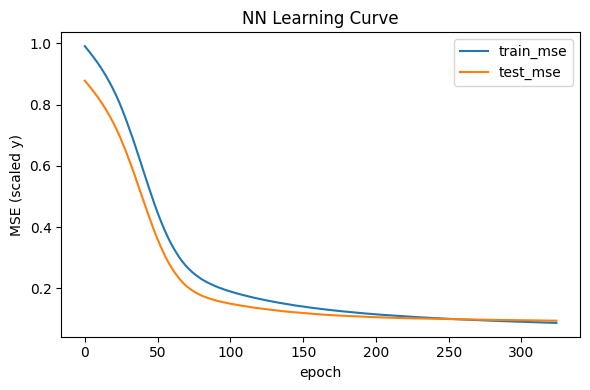

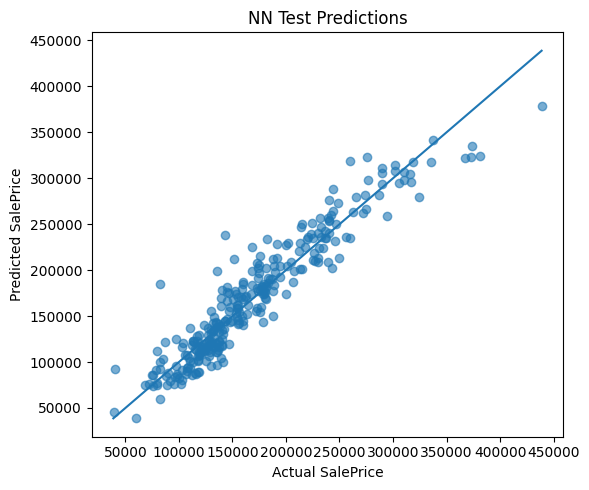

In [8]:
plt.figure(figsize=(6,4))
plt.plot(nn.train_losses, label="train_mse")
if len(nn.test_losses) >0:
    plt.plot(nn.test_losses, label="test_mse")
plt.xlabel("epoch")
plt.ylabel("MSE (scaled y)")
plt.title("NN Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
plt.scatter(yt, y_hat_ts, alpha=0.6)
mn =min(yt.min(), y_hat_ts.min())
mx =max(yt.max(), y_hat_ts.max())
plt.plot([mn,mx],[mn,mx])
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("NN Test Predictions")
plt.tight_layout()
plt.show()
